In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/home/pratik/ML and DL projects/expense-predictor/backend/configs/data/student_expenses.csv')
df

,Date,Amount,Type,Category,Notes
0,2025-09-01,12000.00,Fixed,Housing,Rent - monthly
1,2025-09-01,44.99,Variable,Food & Dining - Restaurants,late night pizza w/ roommates
2,2025-09-01,230.99,Variable,Entertainment - Games,concert tickets
3,2025-09-02,245.50,Variable,Education - Printing,lab manual printing
4,2025-09-03,184.50,Variable,Food & Dining - Coffee,NaN
...,...,...,...,...,...
445,2026-08-24,82.99,Variable,Food & Dining - Groceries,coffee and work
446,2026-08-25,132.99,Variable,Transportation - Fuel,rapido to college
447,2026-08-27,70.00,Variable,Food & Dining - Restaurants,dominos pizza fri night
448,2026-08-27,292.95,Variable,Food & Dining - Groceries,ate out with batch


In [4]:
df.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      450 non-null    object 
 1   Amount    450 non-null    float64
 2   Type      450 non-null    object 
 3   Category  450 non-null    object 
 4   Notes     411 non-null    object 
dtypes: float64(1), object(4)
memory usage: 17.7+ KB


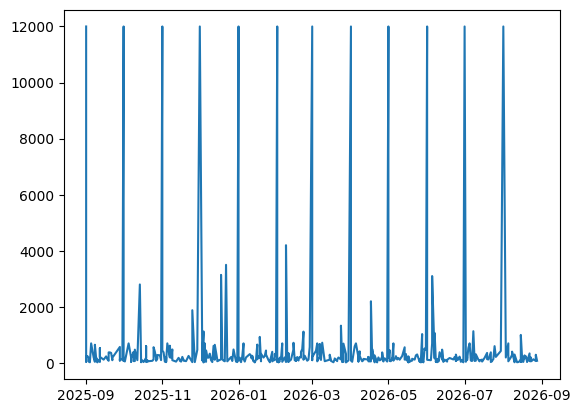

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
plt.plot(df['Date'],df['Amount'])

Model Prophet

In [7]:
from prophet import Prophet

/home/pratik/miniconda3/envs/ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [11]:
df = df.rename(columns={'Date': 'ds', 'Amount': 'y'})
df.head()

,ds,y,Type,Category,Notes
0,2025-09-01,12000.00,Fixed,Housing,Rent - monthly
1,2025-09-01,44.99,Variable,Food & Dining - Restaurants,late night pizza w/ roommates
2,2025-09-01,230.99,Variable,Entertainment - Games,concert tickets
3,2025-09-02,245.50,Variable,Education - Printing,lab manual printing
4,2025-09-03,184.50,Variable,Food & Dining - Coffee,NaN


In [12]:
model_p = Prophet()
model_p.fit(df)

13:45:44 - cmdstanpy - INFO - Chain [1] start processing


13:45:44 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = model_p.make_future_dataframe(periods = 365)
pred = model_p.predict(future)

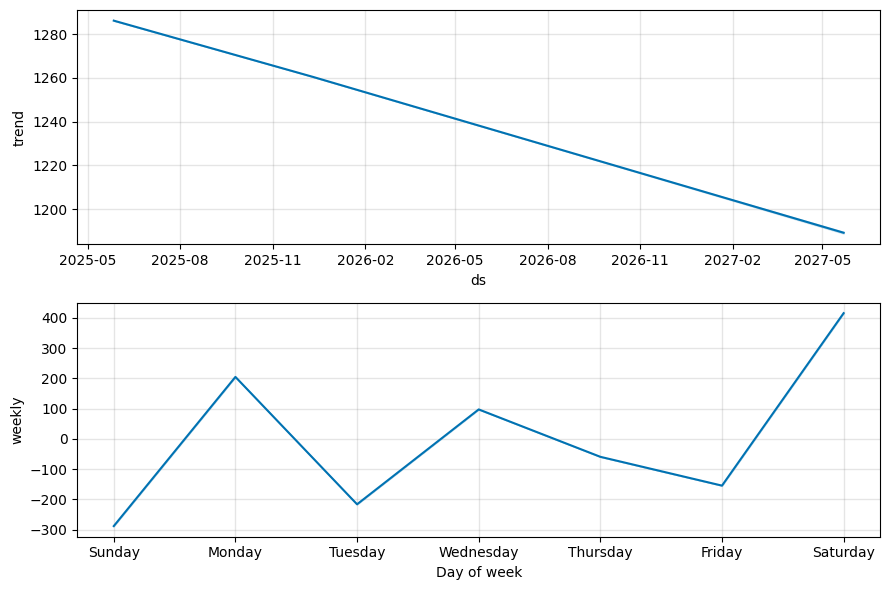

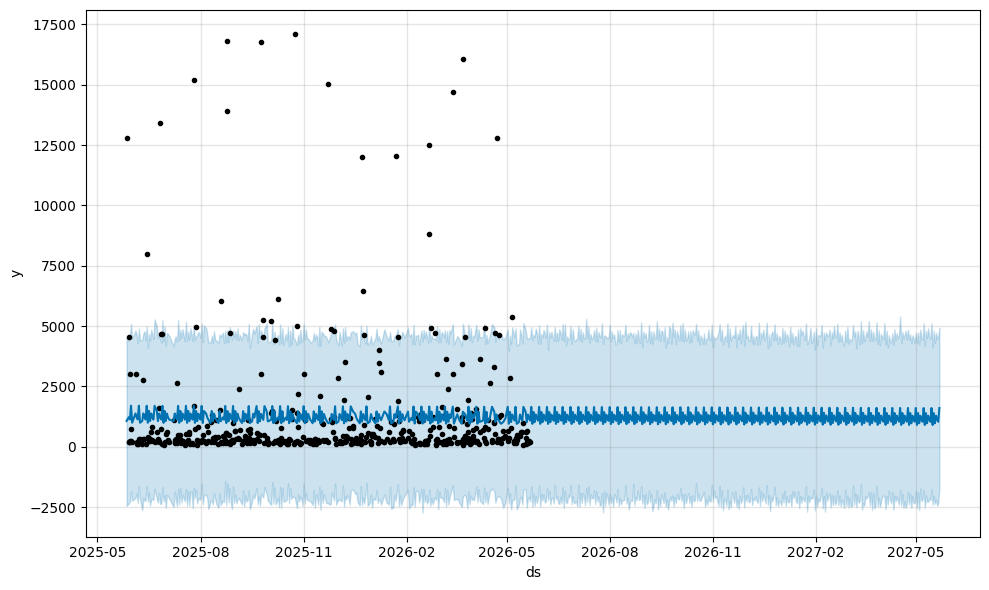

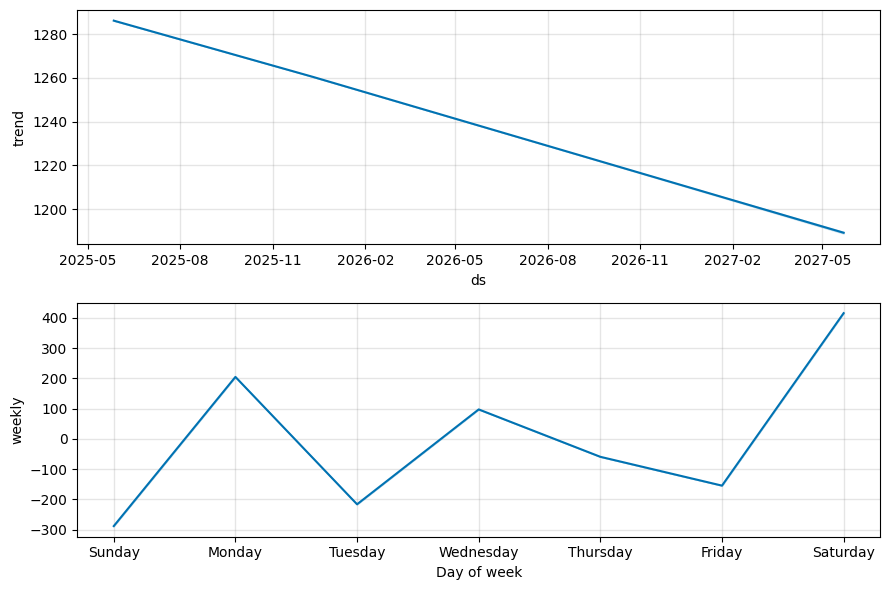

In [16]:
model_p.plot(pred)
model_p.plot_components(pred)